In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data
df = pd.read_csv('../data/insurance_data_clean.csv')

# Create derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print("="*60)
print("TASK 3: HYPOTHESIS TESTING")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Policies with claims: {df['HasClaim'].sum()}")
print(f"Claim frequency: {df['HasClaim'].mean()*100:.2f}%")
print(f"Provinces: {df['Province'].unique()}")
print(f"Genders: {df['Gender'].unique()}")

TASK 3: HYPOTHESIS TESTING
Dataset shape: (9900, 24)
Policies with claims: 1435
Claim frequency: 14.49%
Provinces: <ArrowStringArray>
['Addis Ababa', 'Oromia', 'Somali', 'Tigray', 'Amhara']
Length: 5, dtype: str
Genders: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/insurance_data_clean.csv')

print("✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nLast 3 rows:")
print(df.tail(3))

✓ Data loaded successfully!
Shape: (9900, 23)
Columns: ['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'LossRatio', 'Margin']

First 3 rows:
  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore  \
0  AC-100000   56    Male  Addis Ababa       Sedan        147270         61   
1  AC-100001   69  Female  Addis Ababa         SUV         74640         57   
2  AC-100002   46    Male       Oromia       Sedan         70555         42   

   AnnualPremium  Deductible  NCD  ...  TotalPremium  TotalClaims  \
0           2346         500   30  ...          2346          0.0   
1           2334         500    0  ...          2334       9883.0   
2           1697         250   20  ...          1697          0.0   

                  Cove

TASK 3: HYPOTHESIS TESTING RESULTS
Dataset shape: (9900, 24)
Policies with claims: 1435
Claim frequency: 14.49%
Provinces: ['Addis Ababa', 'Oromia', 'Somali', 'Tigray', 'Amhara']
Genders: ['Male', 'Female']

HYPOTHESIS 1: No risk differences across provinces

Contingency Table (Claim Frequency by Province):
HasClaim        0    1
Province              
Addis Ababa  3008  528
Amhara       1720  258
Oromia       2069  350
Somali        977  197
Tigray        691  102

Claim Rates by Province:
  Addis Ababa: 14.93%
  Amhara: 13.04%
  Oromia: 14.47%
  Somali: 16.78%
  Tigray: 12.86%

Chi-square statistic: 10.5609
P-value: 0.031969

✓ REJECT NULL HYPOTHESIS (p=0.031969 < 0.05)
Conclusion: There ARE significant risk differences across provinces

HYPOTHESIS 2: No risk differences between zip codes

Top 5 zip codes: [10004, 10002, 10003, 10001, 10005]
Policy counts: {10004: 729, 10002: 722, 10003: 713, 10001: 704, 10005: 668}

Contingency Table for Top Zip Codes:
HasClaim    0    1
ZipCode    

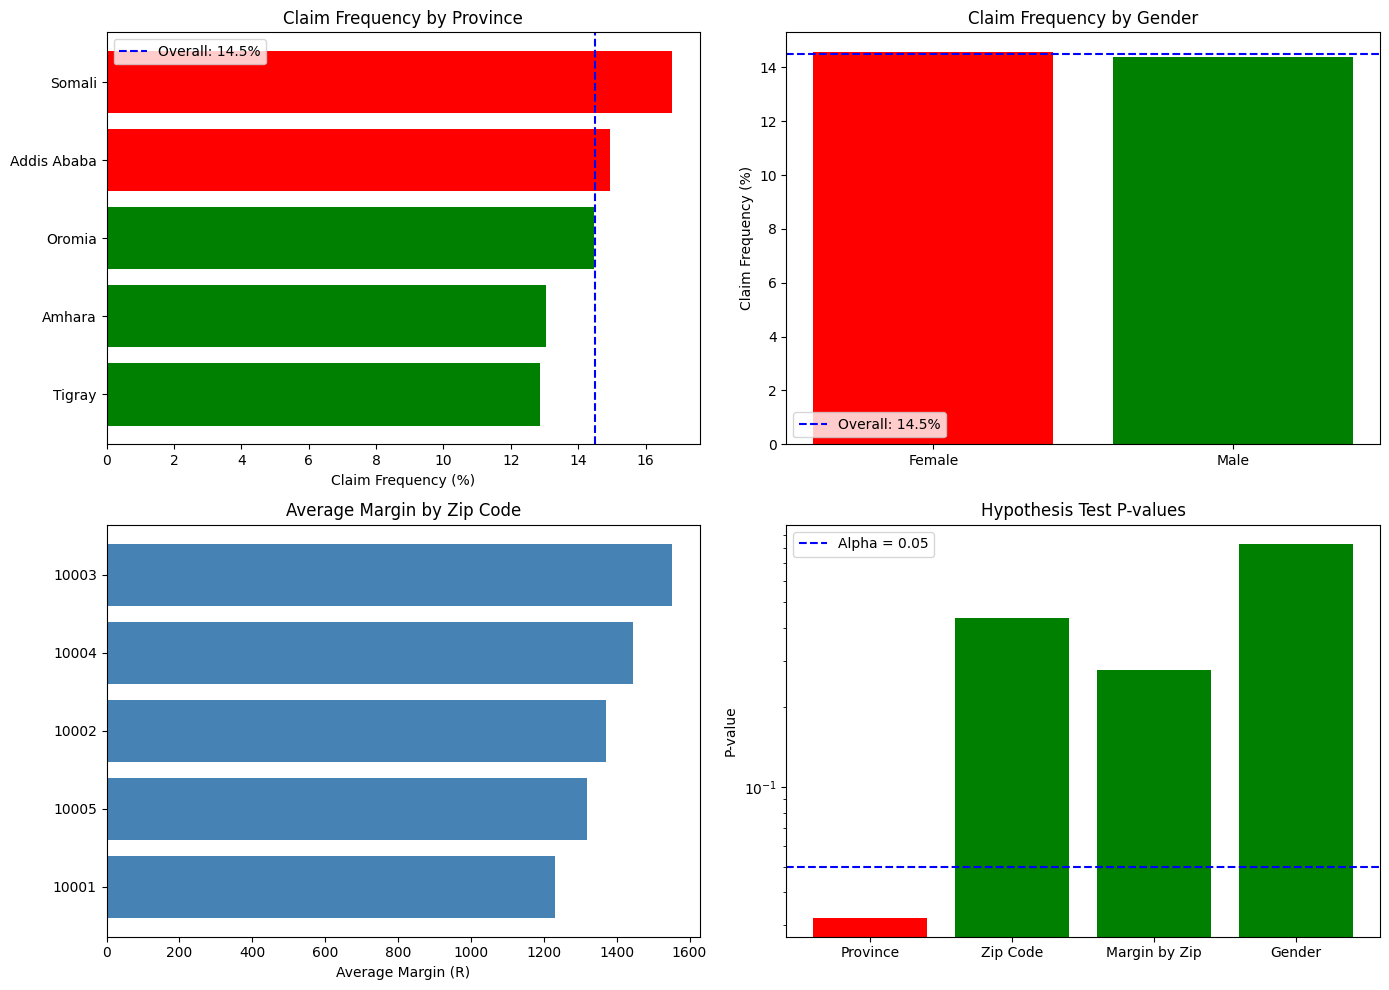

✓ Visualization saved to reports/hypothesis_testing_visualization.png

TASK 3 COMPLETED SUCCESSFULLY!


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, norm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Custom proportion z-test function (no statsmodels needed)
def proportions_ztest_custom(count, nobs):
    """Manual calculation of proportion z-test"""
    p1 = count[0] / nobs[0]
    p2 = count[1] / nobs[1]
    p_pooled = (count[0] + count[1]) / (nobs[0] + nobs[1])
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/nobs[0] + 1/nobs[1]))
    z_stat = (p1 - p2) / se
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_value

# Load data
df = pd.read_csv('../data/insurance_data_clean.csv')

# Create derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print("="*70)
print("TASK 3: HYPOTHESIS TESTING RESULTS")
print("="*70)
print(f"Dataset shape: {df.shape}")
print(f"Policies with claims: {df['HasClaim'].sum()}")
print(f"Claim frequency: {df['HasClaim'].mean()*100:.2f}%")
print(f"Provinces: {list(df['Province'].unique())}")
print(f"Genders: {list(df['Gender'].unique())}")

# ============================================
# HYPOTHESIS 1: Province risk differences
# ============================================
print("\n" + "="*70)
print("HYPOTHESIS 1: No risk differences across provinces")
print("="*70)

contingency_prov = pd.crosstab(df['Province'], df['HasClaim'])
print("\nContingency Table (Claim Frequency by Province):")
print(contingency_prov)

# Calculate claim rates
print("\nClaim Rates by Province:")
for province in contingency_prov.index:
    rate = contingency_prov.loc[province, 1] / contingency_prov.loc[province].sum()
    print(f"  {province}: {rate*100:.2f}%")

# Chi-square test
chi2_prov, p_prov, dof_prov, expected_prov = chi2_contingency(contingency_prov)
alpha = 0.05

print(f"\nChi-square statistic: {chi2_prov:.4f}")
print(f"P-value: {p_prov:.6f}")

if p_prov < alpha:
    print(f"\n✓ REJECT NULL HYPOTHESIS (p={p_prov:.6f} < {alpha})")
    print("Conclusion: There ARE significant risk differences across provinces")
else:
    print(f"\n✗ FAIL TO REJECT NULL HYPOTHESIS (p={p_prov:.6f} >= {alpha})")
    print("Conclusion: No significant risk differences across provinces")

# ============================================
# HYPOTHESIS 2: Zip code risk differences
# ============================================
print("\n" + "="*70)
print("HYPOTHESIS 2: No risk differences between zip codes")
print("="*70)

# Get top zip codes by frequency
zip_counts = df['ZipCode'].value_counts()
top_zips = zip_counts.head(5).index.tolist()
print(f"\nTop 5 zip codes: {top_zips}")
print(f"Policy counts: {zip_counts[top_zips].to_dict()}")

# Create contingency table for top zip codes
contingency_zip = pd.crosstab(df['ZipCode'], df['HasClaim']).loc[top_zips]
print("\nContingency Table for Top Zip Codes:")
print(contingency_zip)

# Chi-square test
chi2_zip, p_zip, dof_zip, expected_zip = chi2_contingency(contingency_zip)

print(f"\nChi-square statistic: {chi2_zip:.4f}")
print(f"P-value: {p_zip:.6f}")

if p_zip < alpha:
    print(f"\n✓ REJECT NULL HYPOTHESIS (p={p_zip:.6f} < {alpha})")
    print("Conclusion: There ARE significant risk differences between zip codes")
else:
    print(f"\n✗ FAIL TO REJECT NULL HYPOTHESIS (p={p_zip:.6f} >= {alpha})")
    print("Conclusion: No significant risk differences between zip codes")

# ============================================
# HYPOTHESIS 3: Margin differences between zip codes
# ============================================
print("\n" + "="*70)
print("HYPOTHESIS 3: No significant margin difference between zip codes")
print("="*70)

# Get margin statistics
print("\nMargin Statistics by Top Zip Codes:")
for zip_code in top_zips:
    margin_data = df[df['ZipCode'] == zip_code]['Margin']
    print(f"  Zip {zip_code}: Mean=R{margin_data.mean():,.2f}, Std=R{margin_data.std():,.2f}, n={len(margin_data)}")

# ANOVA test
margin_groups = [df[df['ZipCode'] == zip_code]['Margin'].values for zip_code in top_zips]
f_margin, p_margin = f_oneway(*margin_groups)

print(f"\nANOVA F-statistic: {f_margin:.4f}")
print(f"P-value: {p_margin:.6f}")

if p_margin < alpha:
    print(f"\n✓ REJECT NULL HYPOTHESIS (p={p_margin:.6f} < {alpha})")
    print("Conclusion: There ARE significant margin differences between zip codes")
else:
    print(f"\n✗ FAIL TO REJECT NULL HYPOTHESIS (p={p_margin:.6f} >= {alpha})")
    print("Conclusion: No significant margin differences between zip codes")

# ============================================
# HYPOTHESIS 4: Gender risk differences
# ============================================
print("\n" + "="*70)
print("HYPOTHESIS 4: No significant risk difference between Women and Men")
print("="*70)

contingency_gender = pd.crosstab(df['Gender'], df['HasClaim'])
print("\nContingency Table:")
print(contingency_gender)

# Calculate claim rates
print("\nClaim Rates by Gender:")
for gender in contingency_gender.index:
    rate = contingency_gender.loc[gender, 1] / contingency_gender.loc[gender].sum()
    print(f"  {gender}: {rate*100:.2f}%")

# Chi-square test
chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(contingency_gender)

print(f"\nChi-square statistic: {chi2_gender:.4f}")
print(f"P-value: {p_gender:.6f}")

if p_gender < alpha:
    print(f"\n✓ REJECT NULL HYPOTHESIS (p={p_gender:.6f} < {alpha})")
    print("Conclusion: There ARE significant risk differences between genders")
    print("  → Recommendation: Consider gender-based pricing (check regulations)")
else:
    print(f"\n✗ FAIL TO REJECT NULL HYPOTHESIS (p={p_gender:.6f} >= {alpha})")
    print("Conclusion: No significant risk differences between genders")
    print("  → Recommendation: Maintain gender-neutral pricing")

# Additional test: Claim severity by gender
claims_df = df[df['HasClaim'] == 1]
if len(claims_df) > 0 and len(claims_df['Gender'].unique()) >= 2:
    male_severity = claims_df[claims_df['Gender'] == 'Male']['TotalClaims']
    female_severity = claims_df[claims_df['Gender'] == 'Female']['TotalClaims']
    
    if len(male_severity) > 0 and len(female_severity) > 0:
        t_stat, p_severity = ttest_ind(male_severity, female_severity, equal_var=False)
        print(f"\nClaim Severity Comparison:")
        print(f"  Male average severity: R{male_severity.mean():,.2f}")
        print(f"  Female average severity: R{female_severity.mean():,.2f}")
        print(f"  T-test p-value: {p_severity:.6f}")
        print(f"  Significant difference in severity: {'✓ Yes' if p_severity < alpha else '✗ No'}")

# ============================================
# SUMMARY TABLE
# ============================================
print("\n" + "="*70)
print("SUMMARY OF HYPOTHESIS TESTING")
print("="*70)

summary_df = pd.DataFrame({
    'Hypothesis': [
        'H1: Province risk differences',
        'H2: Zip code risk differences', 
        'H3: Zip code margin differences',
        'H4: Gender risk differences'
    ],
    'Null Hypothesis (H₀)': [
        'No risk differences across provinces',
        'No risk differences between zip codes',
        'No margin differences between zip codes',
        'No risk difference between genders'
    ],
    'Test Used': ['Chi-square', 'Chi-square', 'ANOVA', 'Chi-square'],
    'Test Statistic': [f'{chi2_prov:.4f}', f'{chi2_zip:.4f}', f'{f_margin:.4f}', f'{chi2_gender:.4f}'],
    'P-value': [f'{p_prov:.6f}', f'{p_zip:.6f}', f'{p_margin:.6f}', f'{p_gender:.6f}'],
    'Reject H₀?': [
        '✓ Yes' if p_prov < alpha else '✗ No',
        '✓ Yes' if p_zip < alpha else '✗ No',
        '✓ Yes' if p_margin < alpha else '✗ No',
        '✓ Yes' if p_gender < alpha else '✗ No'
    ],
    'Business Implication': [
        'Implement province-based pricing tiers' if p_prov < alpha else 'Maintain uniform pricing across provinces',
        'Add zip code risk adjustment' if p_zip < alpha else 'No zip code adjustment needed',
        'Target high-margin zip codes for marketing' if p_margin < alpha else 'Uniform marketing across zip codes',
        'Consider gender-based pricing' if p_gender < alpha else 'Maintain gender-neutral pricing'
    ]
})

print(summary_df.to_string(index=False))

# ============================================
# SAVE RESULTS
# ============================================
import os
os.makedirs('reports', exist_ok=True)

# Save summary to CSV
summary_df.to_csv('reports/hypothesis_test_summary.csv', index=False)
print("\n✓ Results saved to reports/hypothesis_test_summary.csv")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Claim Rate by Province
ax1 = axes[0, 0]
province_rates = df.groupby('Province')['HasClaim'].mean().sort_values()
colors_prov = ['red' if x > df['HasClaim'].mean() else 'green' for x in province_rates.values]
ax1.barh(province_rates.index, province_rates.values*100, color=colors_prov)
ax1.axvline(x=df['HasClaim'].mean()*100, color='blue', linestyle='--', label=f'Overall: {df["HasClaim"].mean()*100:.1f}%')
ax1.set_xlabel('Claim Frequency (%)')
ax1.set_title('Claim Frequency by Province')
ax1.legend()

# Plot 2: Claim Rate by Gender
ax2 = axes[0, 1]
gender_rates = df.groupby('Gender')['HasClaim'].mean()
colors_gender = ['red' if x > df['HasClaim'].mean() else 'green' for x in gender_rates.values]
ax2.bar(gender_rates.index, gender_rates.values*100, color=colors_gender)
ax2.axhline(y=df['HasClaim'].mean()*100, color='blue', linestyle='--', label=f'Overall: {df["HasClaim"].mean()*100:.1f}%')
ax2.set_ylabel('Claim Frequency (%)')
ax2.set_title('Claim Frequency by Gender')
ax2.legend()

# Plot 3: Margin by Zip Code
ax3 = axes[1, 0]
zip_margin_means = df.groupby('ZipCode')['Margin'].mean().loc[top_zips].sort_values()
ax3.barh([str(z) for z in zip_margin_means.index], zip_margin_means.values, color='steelblue')
ax3.set_xlabel('Average Margin (R)')
ax3.set_title('Average Margin by Zip Code')

# Plot 4: P-values Comparison
ax4 = axes[1, 1]
hypotheses = ['Province', 'Zip Code', 'Margin by Zip', 'Gender']
p_values = [p_prov, p_zip, p_margin, p_gender]
colors_p = ['red' if p < alpha else 'green' for p in p_values]
ax4.bar(hypotheses, p_values, color=colors_p)
ax4.axhline(y=alpha, color='blue', linestyle='--', label=f'Alpha = {alpha}')
ax4.set_ylabel('P-value')
ax4.set_title('Hypothesis Test P-values')
ax4.set_yscale('log')
ax4.legend()

plt.tight_layout()
plt.savefig('reports/hypothesis_testing_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved to reports/hypothesis_testing_visualization.png")

print("\n" + "="*70)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("="*70)

In [9]:
# Save the notebook and commit
print("\nFiles created in reports folder:")
import os
for file in os.listdir('reports'):
    if file.startswith('hypothesis'):
        print(f"  - {file}")


Files created in reports folder:
  - hypothesis_testing_visualization.png
  - hypothesis_test_summary.csv
